# Uncertainty partitioning of BCD-ME figure

Maps of internal spread, obs spread, (model spread for supp docs), (and dominant uncertainty?) globally, of 
```
| mean T | days > mean 30 C |
| sum T  | days > max 100 F |

```

In [3]:
import xarray as xr
import xesmf as xe
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import string
import glob
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

from cartopy import crs as ccrs
import cmocean
from tqdm.notebook import tqdm
from distributed import Client

from funcs_support import get_params,get_filepaths,utility_save,utility_print
from funcs_processing import calc_uncerts
dir_list = get_params()
from fsspec.implementations import local
fs = local.LocalFileSystem()

from funcs_plot import plot_map, vals_to_color_triangle


In [4]:
# Start dask client# Start dask client
client = Client()
display(client)

/glade/u/home/schwarzwald/.conda/envs/enso_imp/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44869 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/44869/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/44869/status,Workers: 2
Total threads: 2,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37513,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/44869/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40055,Total threads: 1
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/proxy/42143/status,Memory: 5.00 GiB
Nanny: tcp://127.0.0.1:41871,


In [5]:
df = get_filepaths(source_dir = 'proc')

In [6]:
# Polynomial sums
params = {'tassumpoly':{'varname':'tassumpoly',
                        'src':'qdm-qplad',
                       'query':'varname == "tassumpoly"',
                       'desc':'sum poly days',
                       'func':lambda x: x.sel(degree=1)}}

# Temporal means
for var in ['tasmax','tas']:
    params[var+'mean'] = {'varname':var,
                          'src':'qdm',
                           'query':'varname == "'+var+'" and suffix != suffix', # Ensuring empty suffix field (instead of, say, "CONUS")
                           'desc':'mean of '+var,
                           'func':lambda x: x.mean(['dayofyear','year'])} 
# Huge graph size otherwise.... 
#params['tasmean']['chunk'] = {'lat':1,'lon':1}

# Days above threshold
for thresh in [30,35]:
    params['tasdays_above'+str(thresh)] = {'varname':'tasbinC',
                                           'src':'qdm-qplad',
                                           'query':'varname == "tasbinC"',
                                           'desc':'days above '+str(thresh),
                                           'func':lambda x: x.sel(binC=slice(thresh,None)).sum('binC'),
                                           'chunk':{'lat':200,'lon':200}}

# Days above threshold from the 1 deg, only bias-corrected runs
for thresh in [30,35]:
    params['tasdays_above'+str(thresh)+'_1deg'] = {'varname':'tas',
                                                   'src':'qdm',
                                           'query':'varname == "tas"',
                                           'desc':'days above '+str(thresh)+', from only BC runs',
                                           'func':lambda x: ((x-273.15)>thresh).sum('dayofyear').mean('year'),
                                           }

In [7]:
# Get paths of BCD-ME files
bcd_fns = pd.DataFrame({'path':np.sort(glob.glob(dir_list['bcd_me']+'*.zarr'))})
bcd_fns['model'] = [re.split(r'\.',re.split(r'\_',fn)[-1])[0] for fn in bcd_fns.path]
bcd_fns['typ'] = [re.split(r'_',re.split(r'\/',fn)[-1])[2] for fn in bcd_fns.path.values]
modlist = bcd_fns['model'].unique()
bcd_fns = bcd_fns.set_index(['typ','model'])

In [8]:
gwls = [0.61,1,2,3]
max_runs = 12

In [9]:
max_runs = 12

uncerts = {}

overwrite = False

for var,p in params.items():
    if var not in uncerts:
        output_fn = dir_list['aux_bigmem']+var+'_uncertcalc_tmp.zarr'
        if overwrite or (not fs.exists(output_fn)):
        
            dss = []
            for mod in tqdm(modlist):
                
                ds_tmp = xr.open_zarr(bcd_fns.loc[(p['src'],mod)].path,decode_timedelta=False).sel(gwl=gwls)
                if p['varname'] not in ds_tmp:
                    print(f'{p['varname']} not found in {bcd_fns.loc[(p['src'],mod)].path}, skipped!')
                    continue
                if 'chunk' in p:
                    ds_tmp = ds_tmp.chunk(p['chunk'])

                ds_tmp = ds_tmp.sel(proj_base = [mod for mod in ds_tmp.proj_base.values if mod in ['ERA5','MERRA2','JRA-3Q','GMFD']])

                # Get runs to process
                has_data_tmp = ds_tmp.has_data.sel(variable=p['varname'],gwl=gwls).load()
                
                has_data_tmp = has_data_tmp.sortby([has_data_tmp.isel(gwl=-x) for x in np.arange(1,has_data_tmp.sizes['gwl']+1)],
                                                    ascending=False)
                has_data_tmp = has_data_tmp.isel(idv = slice(0,max_runs))
                
                runs_proc = [tuple(str(has_data_tmp.isel(idv=x)[v].values) for v in ['model','experiment','run'])
                                 for x in np.arange(has_data_tmp.sizes['idv'])]
            
                #------ processing ------
                ds_tmp = ds_tmp[[p['varname']]]
                ds_tmp = ds_tmp.set_index(idv = ['model','experiment','run']).sel(idv = runs_proc)

                ds_tmp = ds_tmp.assign_coords({'runid':(('idv'),np.arange(0,ds_tmp.sizes['idv']))})
                
                # Get statistic
                ds_tmp = p['func'](ds_tmp[p['varname']])
                # Get change in statistic
                ds_tmp = ds_tmp.sel(gwl=slice(1,3)) - ds_tmp.sel(gwl=0.61)
                
                # Compute
                dss.append(ds_tmp.compute())
        
            dss = xr.concat(dss,dim='idv').reset_index('idv').to_dataset(name=p['varname'])
    
            dss.attrs['SOURCE'] = 'figures_datasummary.ipynb'
            dss.attrs['DESCRIPTION'] = p['desc']
            
            
            print('Computing/saving '+p['desc'])
            utility_save(dss,output_fn,zarr_mode = 'w',save_kwargs = {'zarr_format':3})

        else:
            print('Loading '+output_fn)

        dss = xr.open_zarr(output_fn)
        dss = dss[p['varname']].drop_vars('run').rename({'runid':'run'})
        dss = dss.set_index(idv = ['model','run']).unstack()
        dss = dss.chunk({'proj_base':-1,'model':-1,'run':-1})
        print('calculating uncertainties...')
        # Map blocks to help dask with memory management
        uncerts[var] = xr.map_blocks(calc_uncerts,dss).compute()



Loading /glade/derecho/scratch/schwarzwald/aux_data/tassumpoly_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasmaxmean_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasmean_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasdays_above30_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasdays_above35_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasdays_above30_1deg_uncertcalc_tmp.zarr
calculating uncertainties...
Loading /glade/derecho/scratch/schwarzwald/aux_data/tasdays_above35_1deg_uncertcalc_tmp.zarr
calculating uncertainties...


In [10]:
# 1h 25m 
# 11 m
# 1h 32

In [11]:
def get_colors(ds_uncerts):
    ''' Turn vals_to_color_triangle colors into rgb values '''
    ds_tmp = (ds_uncerts.sel(typ='norm').to_dataarray().
              to_dataset(name='relvar').
              stack(allv = [d for d in ds_uncerts.sizes if d not in ['typ','variable']]))
    # Turn scenario, model, internal into color triangle colors
    ds_tmp['colors'] = xr.DataArray(data=vals_to_color_triangle(ds_tmp['relvar'],
                                                                dim='variable',
                                                                col_names = {'r':'uncint',
                                                                             'g':'uncobs',
                                                                             'b':'uncmod'}),
                                    dims=['allv'])
    ds_tmp['rgbs'] = xr.DataArray(data=[mcolors.to_rgb(c) for c in ds_tmp.colors.values],
                                  dims = ['allv','cax'])
    ds_tmp = ds_tmp.unstack()

    return ds_tmp['rgbs']

uncerts_colors = {var:get_colors(ds) for var,ds in uncerts.items()}

/glade/u/home/schwarzwald/projects/bcd_me/figures/diag_domuncert_variousclims.png saved!


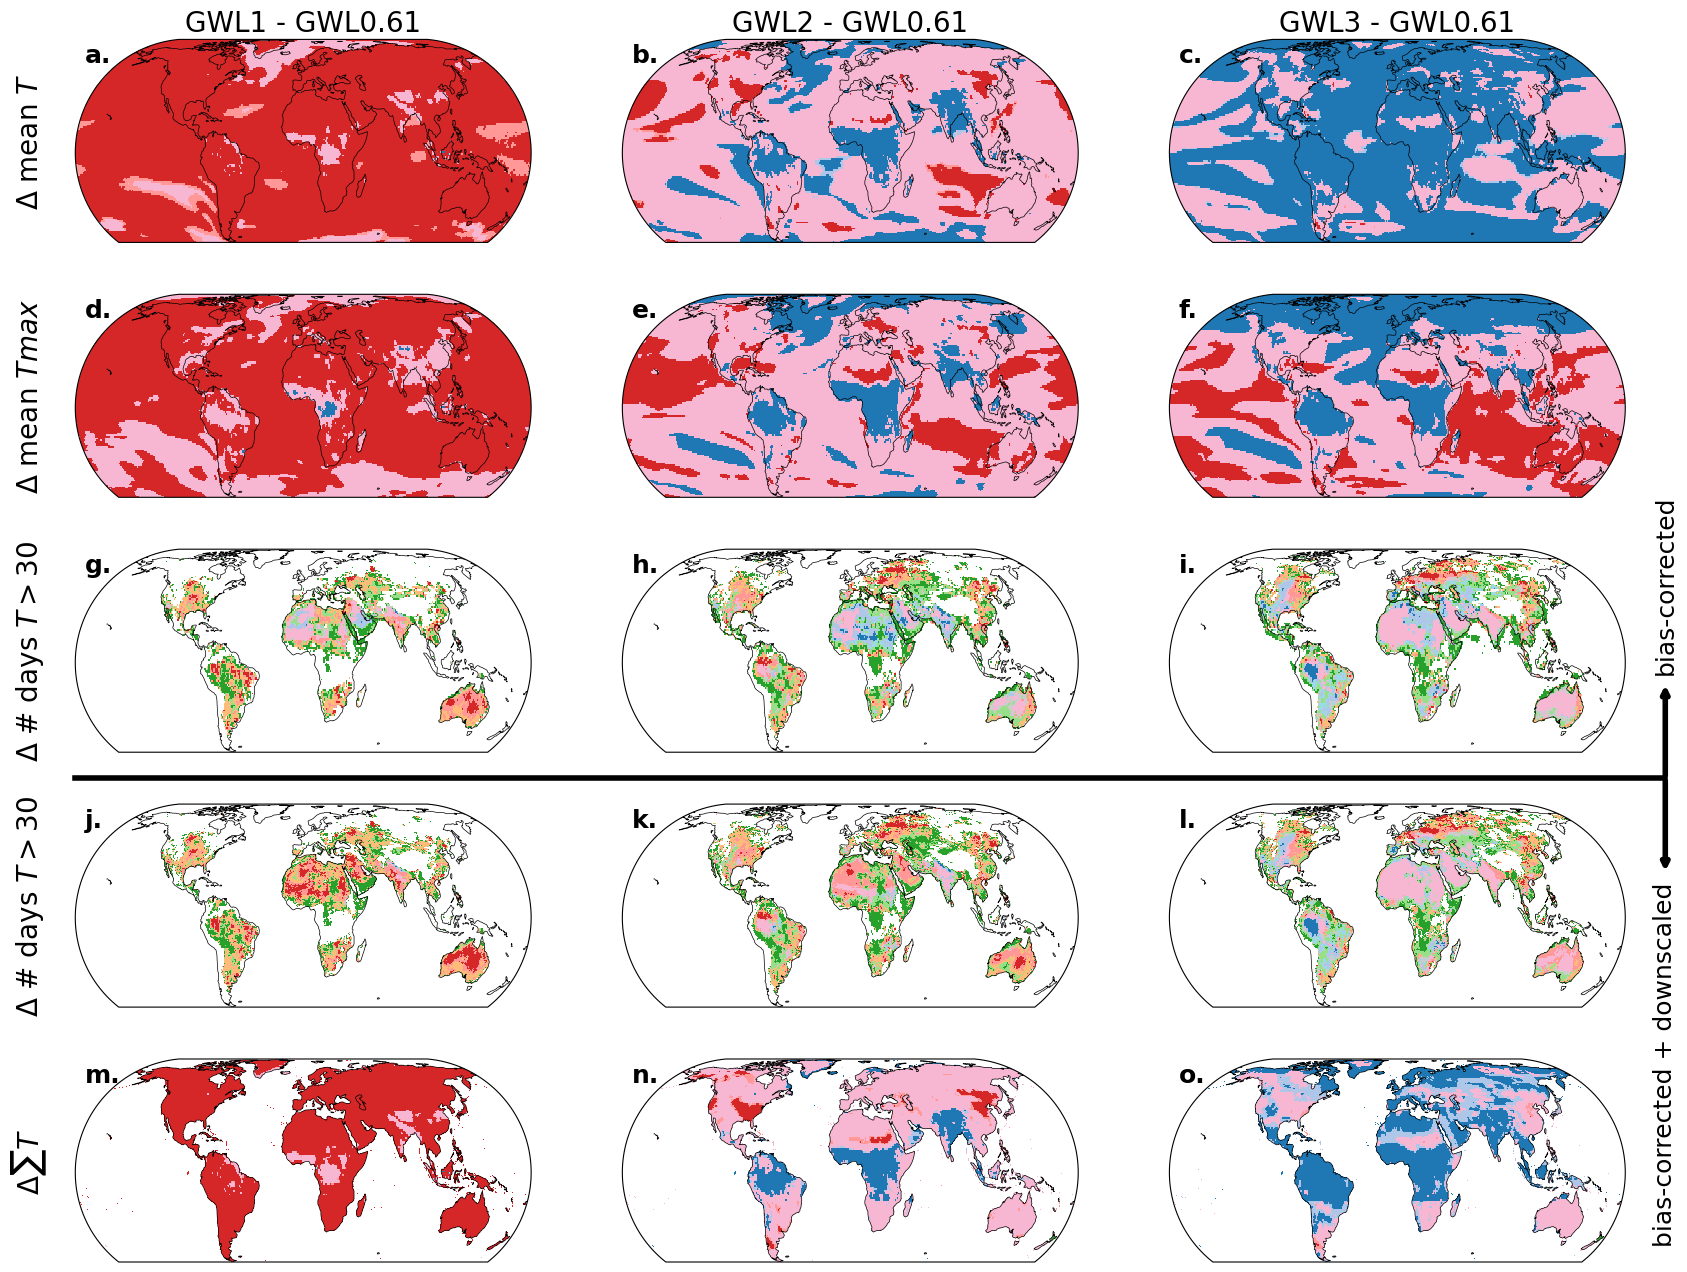

In [12]:

save_fig = True
output_fn = dir_list['figs']+'diag_domuncert_variousclims.png'


gwls = [1,2,3]
vars = ['tasmean','tasmaxmean','tasdays_above30_1deg','tasdays_above30','tassumpoly']

vardescs = {'tasmean':r'$\Delta$ mean $T$',
          'tassumpoly':r'$\Delta \sum T $',
          'tasdays_above30':r'$\Delta $ # days $T>30$',#+'\n(downscaled)',
         'tasdays_above30_1deg':r'$\Delta $ # days $T>30$',#+'\n(not downscaled)',
          'tasmaxmean':r'$\Delta$ mean $Tmax$'}

fig = plt.figure(figsize=(20,16))
axs = np.array([[None]*len(gwls)]*len(vars))
plt.tight_layout()

for row_idx,var in enumerate(vars):
    for col_idx,gwl in enumerate(gwls):
        axs[row_idx,col_idx] = plt.subplot(len(vars),len(gwls),
                         row_idx*len(gwls)+col_idx+1,
                         projection=ccrs.EckertIV())

        xx,yy = np.meshgrid(uncerts_colors[var].lon,uncerts_colors[var].lat)


        plt.pcolormesh(xx,yy,
                       uncerts_colors[var].sel(gwl=gwl).transpose('lat','lon','cax'),
                       shading='nearest',
                      transform=ccrs.PlateCarree())
        axs[row_idx,col_idx].coastlines(linewidth=0.5)
        

        if row_idx == 0:
            #axs[row_idx,col_idx].set_title('GWL '+str(gwl)+' - [1982-2001]',fontsize=20)
            axs[row_idx,col_idx].set_title('GWL'+str(gwl)+' - GWL0.61',fontsize=20)
        if col_idx == 0:
            axs[row_idx,col_idx].annotate(vardescs[var],(-0.1,0.5),xycoords='axes fraction',
                        ha='center',va='center',
                        rotation=90,
                       fontsize=20)

        # Subplot lettering
        axs[row_idx,col_idx].text(
            0.02, 0.98, string.ascii_lowercase[row_idx*len(gwls)+col_idx]+'.',             
            transform=axs[row_idx,col_idx].transAxes,ha='left', va='top',
            fontsize=18,fontweight='bold',
        )


# 
arrow_x_offset = 0.02
# --- Identify the row boundary between rows 2 and 3 ---
# We want the line between axes[1, :] and axes[2, :]

# Get their positions in figure coords
top_row_bbox = axs[2, 0].get_position()
bottom_row_bbox = axs[3, 0].get_position()

# The horizontal boundary is halfway between the bottom of row 2 and top of row 3
y_line = (top_row_bbox.y0 + bottom_row_bbox.y1) / 2

# --- Determine left and right span ---
# Span from the left of column 1 to slightly beyond the right of column 3
left = axs[0, 0].get_position().x0
right = axs[0, -1].get_position().x1

right_extended = right + arrow_x_offset

# --- Draw the thick horizontal separator line ---
fig.lines.append(
    plt.Line2D(
        [left, right_extended],
        [y_line, y_line],
        transform=fig.transFigure,
        linewidth=4,
        color="black",
        clip_on=False,
    )
)

# --- Add arrows and vertical labels ---
# Arrow up (above the line)
plt.annotate(
    "", 
    xy=(right_extended, y_line + 0.06),   # arrow tip
    xytext=(right_extended, y_line),      # arrow base
    xycoords=fig.transFigure,
    arrowprops=dict(
        arrowstyle="-|>", 
        lw=4, 
        color="black"
    )
)

plt.text(
    right_extended,        # small horizontal offset
    y_line + 0.065,                # mid-point between base and tip
    "bias-corrected",
    transform=fig.transFigure,
    rotation=90,
    va="bottom",
    ha="center",
    fontsize=18,
)

# Arrow down (below the line)
plt.annotate(
    "",
    xy=(right_extended, y_line - 0.06),
    xytext=(right_extended, y_line),
    xycoords=fig.transFigure,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=4,
        color="black"
    )
)

plt.text(
    right_extended,
    y_line - 0.065,
    "bias-corrected + downscaled",
    transform=fig.transFigure,
    rotation=90,
    va="top",
    ha="center",
    fontsize=18,
)
        

if save_fig:
    plt.savefig(output_fn,dpi=300)
    print(output_fn+' saved!')